Group Names: Andrew Mankin, Ryan 

Only Positive part of the dataset downloaded

In [14]:
import json
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
IMAGE_DIR = "./dataset/images"
JSON_DIR = "./dataset/metadata"
os.makedirs(JSON_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)
start_dir = "./bimcv_covid19_posi_subjects_1"
for root, dirs, files in os.walk(start_dir):
    for filename in files:
        if filename.endswith(".png"):
            new_img_path = os.path.join(IMAGE_DIR, filename)
            new_json_path = os.path.join(JSON_DIR, filename.replace(".png", ".json"))

            img_path = os.path.join(root, filename)
            json_path = os.path.join(root, filename.replace(".png",".json"))

            if os.path.exists(img_path):
                shutil.copy(img_path, new_img_path)
            if os.path.exists(json_path):
                shutil.copy(json_path, new_json_path)

In [20]:
rows = []
for root,dirs, files in os.walk("./dataset/metadata"):
    for file in files:
        img_file = file.replace(".json",".png")
        json_path = os.path.join(root,file)
        with open(json_path) as file:
            data = json.load(file)

        result = data['00104000']['Value'][0]
        # 1: positive 0: negative
        if result.split()[0].split(":")[1] == "covid19_posi":
            covid_result = 1
        else:
            covid_result = 0
        imageType = data["00280004"]['Value'][0]

        rows.append((img_file, imageType, covid_result))
df = pd.DataFrame(rows,columns=["image", "photometric","label"])

In [21]:
df.to_csv("./dataset/labels.csv",index=False)

In [22]:
df

,image,photometric,label
0,sub-S03044_ses-E06790_run-1_bp-chest_vp-pa_dx.png,MONOCHROME1,1
1,sub-S03044_ses-E07712_run-1_bp-chest_vp-ap_cr.png,MONOCHROME2,1
2,sub-S03044_ses-E06138_run-1_bp-chest_vp-ap_cr.png,MONOCHROME2,1
3,sub-S03045_ses-E06910_acq-2_run-1_bp-chest_vp-...,MONOCHROME2,1
4,sub-S03045_ses-E06139_run-1_bp-chest_vp-ap_dx.png,MONOCHROME1,1
...,...,...,...
156,sub-S03082_ses-E06407_acq-2_run-1_bp-chest_vp-...,MONOCHROME2,1
157,sub-S03082_ses-E07936_run-1_bp-chest_vp-ap_dx.png,MONOCHROME1,1
158,sub-S03083_ses-E06837_run-1_bp-chest_vp-pa_dx.png,MONOCHROME2,1
159,sub-S03083_ses-E06611_run-1_bp-chest_vp-ap_cr.png,MONOCHROME2,1


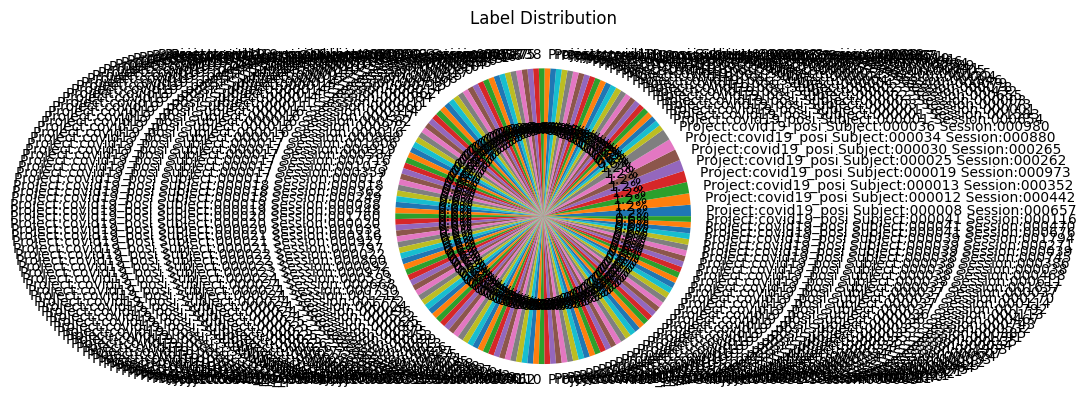

In [19]:
counts = df["label"].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Label Distribution")
plt.show()